# 06 — End-to-end streaming run

Runs the full streaming digital-twin loop over the test window (1 Hz inner loop + event-driven MPC outer loop) and plots cumulative cost, realized prices, and replan events. Expect roughly real-time on CPU.

Requires: scenario generated (`scripts/generate_scenario.py`) and SMARD prices fetched (`scripts/fetch_smard_prices.py`).

Note: NILM training is no longer required. The default disaggregator is a dummy perfect implementation that reads simulator ground truth.

In [1]:
import subprocess, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
# Run the streaming twin for the first 12 simulated hours.
subprocess.run([sys.executable, "-m", "aerogrid.sim.digital_twin",
                "--hours", "12"], check=True)

streaming 2026-04-03T00:00:00+00:00 → 2026-04-03T12:00:00+00:00 (12.0 h)
[2026-04-03T05:59:59+00:00] samples=21,600 replans=111 hitl=0 cost=$2.92 baseline=$5.25 saved=+44.3%
[2026-04-03T11:59:59+00:00] samples=43,200 replans=686 hitl=0 cost=$2.92 baseline=$8.19 saved=+64.3%

=== simulation summary ===
samples:            43,200
replans:            686
hitl prompts:       0
last trigger:       need 1.2kW, current 0.0kW, 24.0kWh / 19.2h
cumulative cost:    $2.92
baseline cost:      $8.19
savings:            +64.3%
log:                /Users/mislavjordanic/Documents/projects/personal_projects/home-energy-planner/data/cache/run_log.jsonl


CompletedProcess(args=['/Users/mislavjordanic/Documents/projects/personal_projects/home-energy-planner/.venv/bin/python', '-m', 'aerogrid.sim.digital_twin', '--hours', '12'], returncode=0)

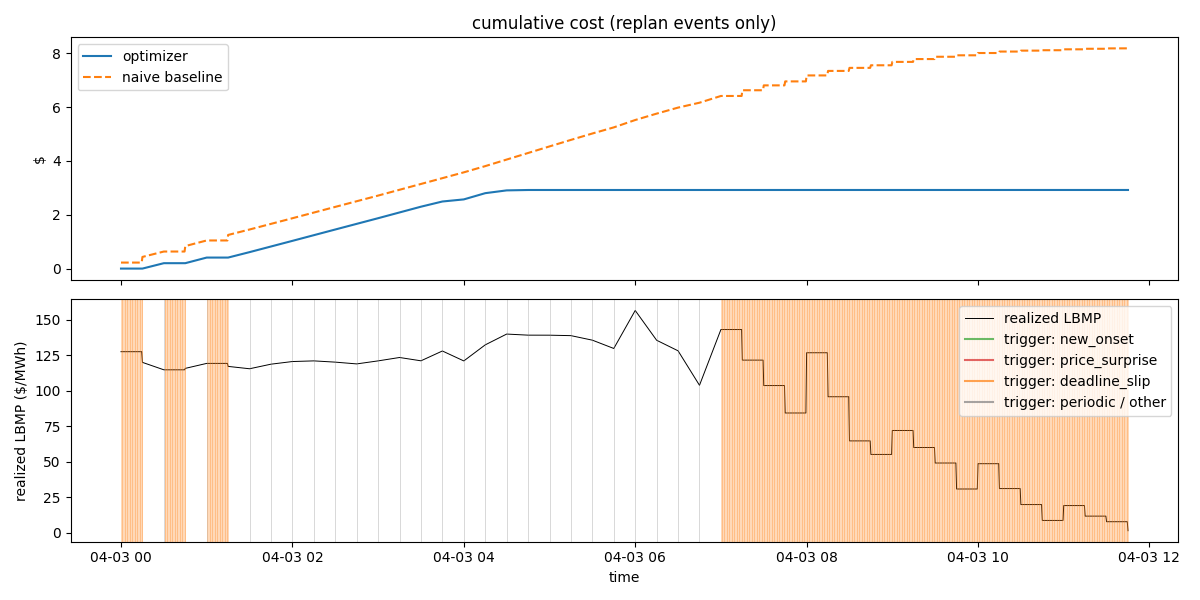

replan events: 686  final cost: $2.92  baseline: $8.19  saved: +64.3%


In [3]:
import pandas as pd, matplotlib.pyplot as plt, json
from matplotlib.lines import Line2D
from IPython import get_ipython
from aerogrid.config import RUN_LOG_PATH

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass

rows = [json.loads(l) for l in RUN_LOG_PATH.read_text().splitlines() if l.strip()]
log = pd.DataFrame(rows)
log["now"] = pd.to_datetime(log["now"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# This blue line is the optimizer's cumulative energy cost over time, sampled only at replan events.
# Every upward step means the controller committed extra energy in that interval, and flat parts mean no additional optimizer cost was added.
# Read it as "how much money the smart policy has spent so far" while the simulation progresses.
ax1.plot(log["now"], log["cumulative_cost"], label="optimizer", color="C0")

# This dashed orange line is a naive baseline cumulative cost built from the same timeline.
# It shows what cost would accumulate without optimization, so the vertical gap versus blue is the savings achieved by smarter control.
# If orange rises faster than blue, the optimizer is avoiding expensive energy periods.
ax1.plot(log["now"], log["cumulative_baseline_cost"], label="naive baseline", linestyle="--", color="C1")
ax1.set_ylabel("$")
ax1.set_title("cumulative cost (replan events only)")
ax1.legend(loc="upper left")

# This black line is the realized LBMP price path seen by the simulator.
# It is the market signal the optimizer reacts to, so spikes indicate expensive windows and drops indicate cheap charging opportunities.
# Comparing this line with the cost curves helps explain why optimizer cost rises early and then often flattens.
ax2.plot(log["now"], log["realized_price"], "k-", lw=0.7, label="realized LBMP")
ax2.set_ylabel("realized LBMP ($/MWh)")
ax2.set_xlabel("time")

# These vertical markers denote replan events and are color-coded by trigger type.
# Dense regions can look like shaded blocks because many triggers happen close together in time, not because area fill is used.
# The colors encode why replanning happened, so you can visually connect controller behavior to changing conditions.
trigger_colors = {
    "new_onset": "C2",
    "price_surprise": "C3",
    "deadline_slip": "C1",
    "periodic": "grey",
}
for _, row in log.iterrows():
    trig = row.get("trigger") or {}
    kind = trig.get("kind") if isinstance(trig, dict) else None
    color = trigger_colors.get(kind, "grey")
    ax2.axvline(row["now"], color=color, alpha=0.35, linewidth=0.6)

# Add a complete legend for the bottom subplot: the price line and all trigger marker categories.
# We use proxy line objects so the legend remains stable and readable even with hundreds of vertical event lines.
trigger_handles = [
    Line2D([0], [0], color="k", lw=0.7, label="realized LBMP"),
    Line2D([0], [0], color="C2", lw=1.5, alpha=0.7, label="trigger: new_onset"),
    Line2D([0], [0], color="C3", lw=1.5, alpha=0.7, label="trigger: price_surprise"),
    Line2D([0], [0], color="C1", lw=1.5, alpha=0.7, label="trigger: deadline_slip"),
    Line2D([0], [0], color="grey", lw=1.5, alpha=0.7, label="trigger: periodic / other"),
]
ax2.legend(handles=trigger_handles, loc="upper right")

plt.tight_layout()
plt.show()

n_replans = len(log)
final_cost = float(log["cumulative_cost"].iloc[-1]) if not log.empty else 0.0
final_baseline = float(log["cumulative_baseline_cost"].iloc[-1]) if not log.empty else 0.0
saved = (1 - final_cost / max(final_baseline, 1e-6)) * 100 if final_baseline > 0 else 0.0
print(f"replan events: {n_replans}  final cost: ${final_cost:.2f}  baseline: ${final_baseline:.2f}  saved: {saved:+.1f}%")

In [5]:
log

,sample,now,p_mains_w,trigger,hitl,plan,commit,realized_price,cumulative_cost,cumulative_baseline_cost
0,1,2026-04-03 00:00:00+00:00,299.181641,"{'kind': 'deadline_slip', 'detail': 'need 3.4k...","{'action': 'ask', 'reason': 'first plan', 'que...","{'slot_start': '2026-04-03T00:00:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",127.53,0.000000,0.223178
1,31,2026-04-03 00:00:30+00:00,306.537842,"{'kind': 'deadline_slip', 'detail': 'need 3.4k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T00:00:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",127.53,0.000000,0.223178
2,61,2026-04-03 00:01:00+00:00,298.865112,"{'kind': 'deadline_slip', 'detail': 'need 3.4k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T00:00:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",127.53,0.000000,0.223178
3,91,2026-04-03 00:01:30+00:00,298.389099,"{'kind': 'deadline_slip', 'detail': 'need 3.4k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T00:00:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",127.53,0.000000,0.223178
4,121,2026-04-03 00:02:00+00:00,297.093445,"{'kind': 'deadline_slip', 'detail': 'need 3.4k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T00:00:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",127.53,0.000000,0.223178
...,...,...,...,...,...,...,...,...,...,...
681,42181,2026-04-03 11:43:00+00:00,301.281311,"{'kind': 'deadline_slip', 'detail': 'need 1.2k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T11:30:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",7.70,2.921728,8.183945
682,42211,2026-04-03 11:43:30+00:00,301.886108,"{'kind': 'deadline_slip', 'detail': 'need 1.2k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T11:30:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",7.70,2.921728,8.183945
683,42241,2026-04-03 11:44:00+00:00,299.796082,"{'kind': 'deadline_slip', 'detail': 'need 1.2k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T11:30:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",7.70,2.921728,8.183945
684,42271,2026-04-03 11:44:30+00:00,295.308929,"{'kind': 'deadline_slip', 'detail': 'need 1.2k...","{'action': 'auto', 'reason': 'within tolerance...","{'slot_start': '2026-04-03T11:30:00+00:00', 'h...","{'remaining_ev_kwh': 24.0, 'ev_power_setpoint_...",7.70,2.921728,8.183945


In [4]:
# Notebook-level smoke checks.
assert not log.empty, 'run_log is empty; digital twin did not emit replan entries'
required_cols = {
    'now', 'trigger', 'cumulative_cost', 'cumulative_baseline_cost', 'commit', 'plan'
}
missing = required_cols.difference(log.columns)
assert not missing, f'missing required columns in run_log: {missing}'
assert (log['cumulative_cost'].diff().fillna(0) >= -1e-9).all(), 'cumulative_cost must be non-decreasing'
assert (log['cumulative_baseline_cost'].diff().fillna(0) >= -1e-9).all(), 'baseline cost must be non-decreasing'
print('Notebook checks passed: end-to-end run produced valid log data.')

Notebook checks passed: end-to-end run produced valid log data.
